# 📊 CNN Model Comparison for Proctoring System

This notebook compares different CNN architectures for detecting cheating behavior using:
- **Tabular CNN**: Using extracted features (HR, VR, Pitch, Yaw)
- **Image CNN**: Using raw face images
- - **Hybrid CNN**: Combining both tabular and image data
- **Pretrained CNN**: Using transfer learning (ResNet, EfficientNet)

In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
from torchvision import transforms

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import os
from PIL import Image
import time
from tqdm.notebook import tqdm

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.7.0+cpu
CUDA available: False
Using device: cpu


## 📂 Load and Explore Data

In [2]:
# Load hybrid features data
df = pd.read_csv('data/hybrid_features.csv').dropna()
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['Label'].value_counts())

# Display first few rows
df.head()

Dataset shape: (741, 7)

Columns: ['timestamp', 'image_filename', 'HR', 'VR', 'Pitch', 'Yaw', 'Label']

Label distribution:
Label
0    381
1    360
Name: count, dtype: int64


,timestamp,image_filename,HR,VR,Pitch,Yaw,Label
0,2025-07-10 12:49:35.764,video00_frame_00000000_t0.2s.jpg,0.717454,0.335667,-2.901720,179.984649,0
1,2025-07-10 12:49:35.931,video00_frame_00000001_t0.3s.jpg,0.673273,0.379814,-3.079370,-179.980070,0
2,2025-07-10 12:49:36.098,video00_frame_00000002_t0.5s.jpg,0.608415,0.363606,-3.067913,-179.918522,0
3,2025-07-10 12:49:36.264,video00_frame_00000003_t0.7s.jpg,0.659800,0.327754,0.011651,-6.675301,0
4,2025-07-10 12:49:36.431,video00_frame_00000004_t0.8s.jpg,0.626019,0.371129,0.003198,-16.926017,0


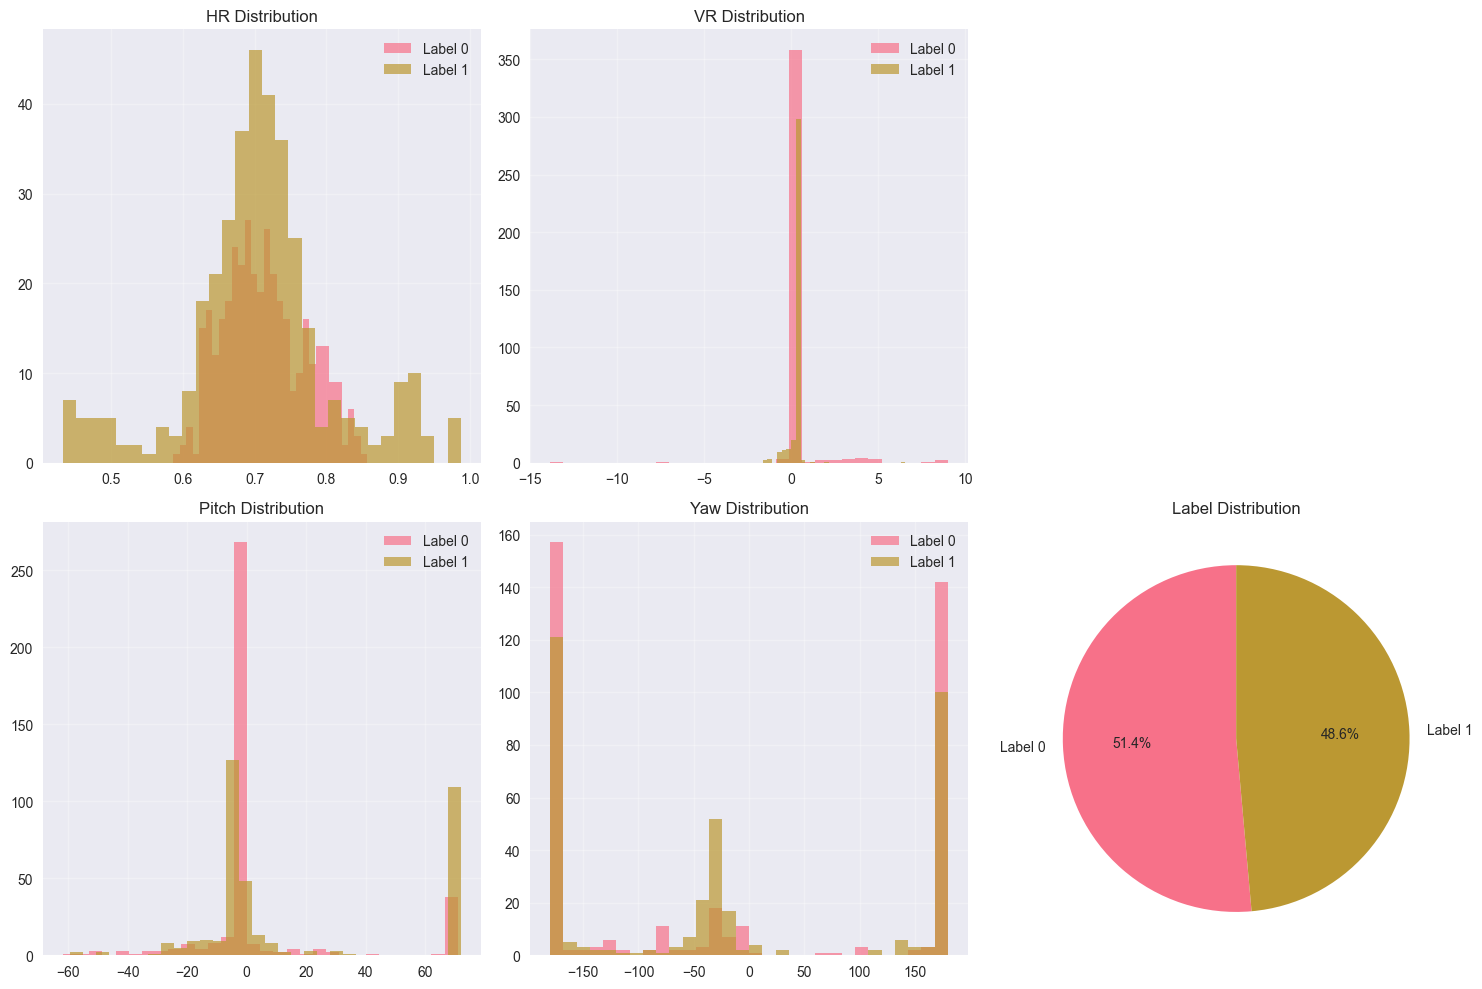

In [3]:
# Visualize data distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['HR', 'VR', 'Pitch', 'Yaw']

# Feature distributions
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    for label in df['Label'].unique():
        data = df[df['Label'] == label][feature]
        axes[row, col].hist(data, alpha=0.7, label=f'Label {label}', bins=30)
    axes[row, col].set_title(f'{feature} Distribution')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

# Label distribution pie chart
label_counts = df['Label'].value_counts()
axes[1, 2].pie(label_counts.values, labels=[f'Label {i}' for i in label_counts.index], 
               autopct='%1.1f%%', startangle=90)
axes[1, 2].set_title('Label Distribution')

# Remove empty subplot
fig.delaxes(axes[0, 2])

plt.tight_layout()
plt.show()

## 🏗️ Model Architectures

In [4]:
# 1. Tabular CNN (MLP-style for tabular data)
class TabularCNN(nn.Module):
    def __init__(self, input_dim=4, num_classes=2):
        super(TabularCNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, num_classes)
        
        self.dropout = nn.Dropout(0.3)
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        
    def forward(self, x):
        x = F.relu(self.batch_norm1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# 2. Simple Image CNN
# This model is a basic CNN for image classification tasks.
# It consists of several convolutional layers followed by fully connected layers.
# It uses ReLU activations and dropout for regularization.
# This architecture is suitable for tasks like image classification where the input is an RGB image.
class ImageCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(ImageCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # For 224x224 input, after 3 pooling: 28x28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        
        x = x.view(-1, 128 * 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 3. Hybrid CNN
# This model combines image and tabular data processing
# HybridCNN combines a CNN for image data and a fully connected network for tabular data.
# It fuses the outputs from both branches before classification.
class HybridCNN(nn.Module):
    def __init__(self, num_classes=2, tabular_input_dim=4):
        super(HybridCNN, self).__init__()
        
        # Image branch
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Calculate conv output size: 224->112->56 after 2 pooling
        self.image_fc = nn.Linear(64 * 56 * 56, 128)
        
        # Tabular branch
        self.tabular_fc = nn.Sequential(
            nn.Linear(tabular_input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32)
        )
        
        # Fusion
        self.fusion_fc = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, image, tabular):
        # Image processing
        x_img = self.pool(F.relu(self.conv1(image)))
        x_img = self.pool(F.relu(self.conv2(x_img)))
        x_img = x_img.view(x_img.size(0), -1)
        x_img = F.relu(self.image_fc(x_img))
        
        # Tabular processing
        x_tab = self.tabular_fc(tabular)
        
        # Fusion
        combined = torch.cat([x_img, x_tab], dim=1)
        output = self.fusion_fc(combined)
        return output

# 4. Transfer Learning CNN (ResNet18)
# This model uses a pre-trained ResNet18 backbone for transfer learning.
# It replaces the final fully connected layer to adapt to the specific number of classes.
# TransferCNN is suitable for image classification tasks where pre-trained models can significantly improve performance.
# It leverages the feature extraction capabilities of ResNet18, which has been trained on a large dataset (ImageNet).
# This architecture is effective for tasks like object recognition, face detection, and other image-related tasks.
# It is particularly useful when the dataset is small or when computational resources are limited.
class TransferCNN(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super(TransferCNN, self).__init__()
        
        self.backbone = models.resnet18(pretrained=pretrained)
        # Replace final layer
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

print("✅ Model architectures defined")

✅ Model architectures defined


## 📊 Dataset Classes

In [5]:
# Tabular Dataset
class TabularDataset(Dataset):
    def __init__(self, csv_path, scaler=None, is_train=True):
        self.df = pd.read_csv(csv_path).dropna()
        self.features = self.df[['HR', 'VR', 'Pitch', 'Yaw']].values.astype(np.float32)
        
        if 'Label' in self.df.columns:
            self.labels = self.df['Label'].values.astype(np.int64)
        else:
            self.labels = None
            
        # Scaling
        if is_train and scaler is None:
            self.scaler = StandardScaler()
            self.features = self.scaler.fit_transform(self.features)
        elif scaler is not None:
            self.scaler = scaler
            self.features = self.scaler.transform(self.features)
        else:
            self.scaler = None
    
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        feature = torch.tensor(self.features[idx], dtype=torch.float32)
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return feature, label
        return feature

# Image Dataset
class ImageDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None):
        self.df = pd.read_csv(csv_path).dropna()
        self.image_dir = image_dir
        self.transform = transform if transform else self.get_default_transform()
        
        if 'Label' in self.df.columns:
            self.labels = self.df['Label'].values.astype(np.int64)
        else:
            self.labels = None
    
    def get_default_transform(self):
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        image_filename = self.df.iloc[idx]['image_filename']
        image_path = os.path.join(self.image_dir, image_filename)
        
        if os.path.exists(image_path):
            image = Image.open(image_path).convert('RGB')
            image = self.transform(image)
        else:
            # Create dummy image if not found
            image = torch.zeros((3, 224, 224), dtype=torch.float32)
        
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, label
        return image

# Hybrid Dataset
class SimpleHybridDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None, scaler=None, is_train=True):
        self.df = pd.read_csv(csv_path).dropna()
        self.image_dir = image_dir
        self.transform = transform if transform else self.get_default_transform()
        
        # Tabular features
        self.tabular_features = self.df[['HR', 'VR', 'Pitch', 'Yaw']].values.astype(np.float32)
        
        # Scaling
        if is_train and scaler is None:
            self.scaler = StandardScaler()
            self.tabular_features = self.scaler.fit_transform(self.tabular_features)
        elif scaler is not None:
            self.scaler = scaler
            self.tabular_features = self.scaler.transform(self.tabular_features)
        else:
            self.scaler = None
            
        if 'Label' in self.df.columns:
            self.labels = self.df['Label'].values.astype(np.int64)
        else:
            self.labels = None
    
    def get_default_transform(self):
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225])
        ])
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Tabular features
        tabular = torch.tensor(self.tabular_features[idx], dtype=torch.float32)
        
        # Image
        image_filename = self.df.iloc[idx]['image_filename']
        image_path = os.path.join(self.image_dir, image_filename)
        
        if os.path.exists(image_path):
            image = Image.open(image_path).convert('RGB')
            image = self.transform(image)
        else:
            image = torch.zeros((3, 224, 224), dtype=torch.float32)
        
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return image, tabular, label
        return image, tabular

print("✅ Dataset classes defined")

✅ Dataset classes defined


## 🔧 Training Functions

In [6]:
def train_model(model, train_loader, val_loader, model_name, num_epochs=10, lr=0.001):
    """
    Generic training function for all model types
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    model = model.to(device)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    start_time = time.time()
    
    print(f"\n🚀 Training {model_name}...")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False)
        for batch_data in train_pbar:
            optimizer.zero_grad()
            
            # Handle different input types
            if len(batch_data) == 2:  # (input, label)
                inputs, labels = batch_data
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
            elif len(batch_data) == 3:  # (image, tabular, label) for hybrid
                images, tabular, labels = batch_data
                images = images.to(device)
                tabular = tabular.to(device)
                labels = labels.to(device)
                outputs = model(images, tabular)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
            train_pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100 * train_correct / train_total:.2f}%'
            })
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False)
            for batch_data in val_pbar:
                # Handle different input types
                if len(batch_data) == 2:
                    inputs, labels = batch_data
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    outputs = model(inputs)
                elif len(batch_data) == 3:
                    images, tabular, labels = batch_data
                    images = images.to(device)
                    tabular = tabular.to(device)
                    labels = labels.to(device)
                    outputs = model(images, tabular)
                
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        # Calculate metrics
        train_acc = 100 * train_correct / train_total
        val_acc = 100 * val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Update best accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
        
        scheduler.step()
        
        print(f'Epoch {epoch+1:2d}/{num_epochs} | '\
              f'Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | '\
              f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}%')
    
    training_time = time.time() - start_time
    print(f'✅ {model_name} training completed in {training_time:.2f}s')
    print(f'🏆 Best validation accuracy: {best_val_acc:.2f}%\n')
    
    return model, history, best_val_acc, training_time

print("✅ Training function defined")

✅ Training function defined


## 📈 Prepare Data and Train Models

In [7]:
# Split data
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Label'])

# Save splits
train_df.to_csv('data/comparison_train.csv', index=False)
val_df.to_csv('data/comparison_val.csv', index=False)

print(f"Train samples: {len(train_df)}, Val samples: {len(val_df)}")
print(f"Train label distribution: {train_df['Label'].value_counts().to_dict()}")
print(f"Val label distribution: {val_df['Label'].value_counts().to_dict()}")

# Training configuration
BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

# Initialize results storage
results = {}
models_dict = {}
training_times = {}

print(f"\nTraining configuration:")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Device: {device}")

Train samples: 592, Val samples: 149
Train label distribution: {0: 304, 1: 288}
Val label distribution: {0: 77, 1: 72}

Training configuration:
Batch size: 16
Epochs: 10
Learning rate: 0.001
Device: cpu


### 1️⃣ Tabular CNN

In [8]:
# 1. Tabular CNN
print("=" * 60)
print("1️⃣ TABULAR CNN")
print("=" * 60)

# Create datasets
tabular_train_dataset = TabularDataset('data/comparison_train.csv', is_train=True)
tabular_val_dataset = TabularDataset('data/comparison_val.csv', 
                                   scaler=tabular_train_dataset.scaler, is_train=False)

# Create data loaders
tabular_train_loader = DataLoader(tabular_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
tabular_val_loader = DataLoader(tabular_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Create and train model
tabular_model = TabularCNN(input_dim=4, num_classes=2)
tabular_model, tabular_history, tabular_best_acc, tabular_time = train_model(
    tabular_model, tabular_train_loader, tabular_val_loader, 
    "Tabular CNN", NUM_EPOCHS, LEARNING_RATE
)

# Store results
results['Tabular CNN'] = {
    'best_val_acc': tabular_best_acc,
    'history': tabular_history,
    'training_time': tabular_time
}
models_dict['Tabular CNN'] = tabular_model

1️⃣ TABULAR CNN

🚀 Training Tabular CNN...


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss: 0.6792 | Train Acc: 54.56% | Val Loss: 0.6462 | Val Acc: 65.10%


Epoch 2/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 0.6116 | Train Acc: 67.23% | Val Loss: 0.6171 | Val Acc: 65.10%


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.6210 | Train Acc: 65.71% | Val Loss: 0.6116 | Val Acc: 67.11%
✅ Tabular CNN training completed in 4.77s
🏆 Best validation accuracy: 70.47%



### 2️⃣ Image CNN

In [9]:
# 2. Image CNN
print("=" * 60)
print("2️⃣ IMAGE CNN")
print("=" * 60)

# Check if images exist
if os.path.exists('data/images/train'):
    # Create datasets
    image_train_dataset = ImageDataset('data/comparison_train.csv', 'data/images/train')
    image_val_dataset = ImageDataset('data/comparison_val.csv', 'data/images/train')
    
    # Create data loaders
    image_train_loader = DataLoader(image_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    image_val_loader = DataLoader(image_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Create and train model
    image_model = ImageCNN(num_classes=2)
    image_model, image_history, image_best_acc, image_time = train_model(
        image_model, image_train_loader, image_val_loader, 
        "Image CNN", NUM_EPOCHS, LEARNING_RATE
    )
    
    # Store results
    results['Image CNN'] = {
        'best_val_acc': image_best_acc,
        'history': image_history,
        'training_time': image_time
    }
    models_dict['Image CNN'] = image_model
    
else:
    print("❌ Image directory not found. Skipping Image CNN.")
    print("Please run frame extraction first to generate images.")

2️⃣ IMAGE CNN



🚀 Training Image CNN...


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss: 0.8607 | Train Acc: 55.41% | Val Loss: 0.6595 | Val Acc: 67.79%


...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 0.1376 | Train Acc: 94.76% | Val Loss: 0.3729 | Val Acc: 89.93%


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.1375 | Train Acc: 94.59% | Val Loss: 0.3493 | Val Acc: 90.60%
✅ Image CNN training completed in 532.29s
🏆 Best validation accuracy: 90.60%



### 3️⃣ Hybrid CNN

In [10]:
# 3. Hybrid CNN
print("=" * 60)
print("3️⃣ HYBRID CNN")
print("=" * 60)

if os.path.exists('data/images/train'):
    # Create datasets
    hybrid_train_dataset = SimpleHybridDataset('data/comparison_train.csv', 'data/images/train', is_train=True)
    hybrid_val_dataset = SimpleHybridDataset('data/comparison_val.csv', 'data/images/train',
                                           scaler=hybrid_train_dataset.scaler, is_train=False)
    
    # Create data loaders
    hybrid_train_loader = DataLoader(hybrid_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    hybrid_val_loader = DataLoader(hybrid_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Create and train model
    hybrid_model = HybridCNN(num_classes=2, tabular_input_dim=4)
    hybrid_model, hybrid_history, hybrid_best_acc, hybrid_time = train_model(
        hybrid_model, hybrid_train_loader, hybrid_val_loader, 
        "Hybrid CNN", NUM_EPOCHS, LEARNING_RATE
    )
    
    # Store results
    results['Hybrid CNN'] = {
        'best_val_acc': hybrid_best_acc,
        'history': hybrid_history,
        'training_time': hybrid_time
    }
    models_dict['Hybrid CNN'] = hybrid_model
    
else:
    print("❌ Image directory not found. Skipping Hybrid CNN.")

3️⃣ HYBRID CNN

🚀 Training Hybrid CNN...


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss: 0.7242 | Train Acc: 59.97% | Val Loss: 0.5676 | Val Acc: 71.14%


Epoch 2/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 0.0550 | Train Acc: 97.64% | Val Loss: 0.4329 | Val Acc: 91.95%


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0440 | Train Acc: 98.48% | Val Loss: 0.4789 | Val Acc: 91.95%
✅ Hybrid CNN training completed in 340.99s
🏆 Best validation accuracy: 91.95%



### 4️⃣ Transfer Learning CNN (ResNet18)

In [11]:
# 4. Transfer Learning CNN
print("=" * 60)
print("4️⃣ TRANSFER LEARNING CNN (ResNet18)")
print("=" * 60)

if os.path.exists('data/images/train'):
    # Use same image datasets as Image CNN
    transfer_train_loader = DataLoader(image_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    transfer_val_loader = DataLoader(image_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Create and train model
    transfer_model = TransferCNN(num_classes=2, pretrained=True)
    transfer_model, transfer_history, transfer_best_acc, transfer_time = train_model(
        transfer_model, transfer_train_loader, transfer_val_loader, 
        "Transfer Learning CNN", NUM_EPOCHS, LEARNING_RATE * 0.1  # Lower LR for pretrained
    )
    
    # Store results
    results['Transfer Learning CNN'] = {
        'best_val_acc': transfer_best_acc,
        'history': transfer_history,
        'training_time': transfer_time
    }
    models_dict['Transfer Learning CNN'] = transfer_model
    
else:
    print("❌ Image directory not found. Skipping Transfer Learning CNN.")

d:\sursat\work\env\CONDA\conda windows\envs\proctoring_system\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\sursat\work\env\CONDA\conda windows\envs\proctoring_system\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


4️⃣ TRANSFER LEARNING CNN (ResNet18)



🚀 Training Transfer Learning CNN...


Epoch 1/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 0.0117 | Train Acc: 99.83% | Val Loss: 0.3115 | Val Acc: 91.95%


Epoch 10/10 [Train]:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.0070 | Train Acc: 99.66% | Val Loss: 0.2426 | Val Acc: 91.95%
✅ Transfer Learning CNN training completed in 671.22s
🏆 Best validation accuracy: 93.96%



In [12]:
# Add this cell after model training and before inference measurement

# Calculate Model Parameters
print("=" * 80)
print("📏 CALCULATING MODEL PARAMETERS")
print("=" * 80)

def count_parameters(model):
    """Count the number of trainable parameters in a model"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Calculate parameters for each trained model
param_counts = {}

for model_name, model in models_dict.items():
    param_count = count_parameters(model)
    param_counts[model_name] = param_count
    
    # Calculate model size estimate
    model_size_mb = (param_count * 4) / (1024 * 1024)  # 4 bytes per float32 parameter
    
    print(f"{model_name}:")
    print(f"  Parameters: {param_count:,}")
    print(f"  Model Size: ~{model_size_mb:.1f} MB")
    print()

print("✅ Parameter counting completed!")

📏 CALCULATING MODEL PARAMETERS
Tabular CNN:
  Parameters: 11,426
  Model Size: ~0.0 MB

Image CNN:
  Parameters: 51,475,010
  Model Size: ~196.4 MB

Hybrid CNN:
  Parameters: 25,722,594
  Model Size: ~98.1 MB

Transfer Learning CNN:
  Parameters: 11,177,538
  Model Size: ~42.6 MB

✅ Parameter counting completed!


In [13]:
# Add this cell after the training completion but before the results comparison

# Cell: Measure Inference Time
print("=" * 80)
print("⏱️ MEASURING INFERENCE TIME")
print("=" * 80)

def measure_inference_time(model, test_loader, model_name, num_runs=100):
    """
    Measure average inference time for a model
    """
    model.eval()
    model = model.to(device)
    
    # Warm up GPU if using CUDA
    if torch.cuda.is_available():
        for _ in range(10):
            with torch.no_grad():
                for batch_data in test_loader:
                    if len(batch_data) == 2:
                        inputs, _ = batch_data
                        inputs = inputs.to(device)
                        _ = model(inputs)
                    elif len(batch_data) == 3:
                        images, tabular, _ = batch_data
                        images = images.to(device)
                        tabular = tabular.to(device)
                        _ = model(images, tabular)
                    break
                break
    
    # Measure inference time
    times = []
    
    with torch.no_grad():
        for run in range(num_runs):
            for batch_data in test_loader:
                # Start timing
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                start_time = time.time()
                
                # Forward pass
                if len(batch_data) == 2:
                    inputs, _ = batch_data
                    inputs = inputs.to(device)
                    outputs = model(inputs)
                elif len(batch_data) == 3:
                    images, tabular, _ = batch_data
                    images = images.to(device)
                    tabular = tabular.to(device)
                    outputs = model(images, tabular)
                
                # End timing
                if torch.cuda.is_available():
                    torch.cuda.synchronize()
                end_time = time.time()
                
                batch_time = (end_time - start_time) * 1000  # Convert to milliseconds
                times.append(batch_time)
                break  # Only measure one batch per run
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    min_time = np.min(times)
    max_time = np.max(times)
    
    print(f"{model_name}:")
    print(f"  Average: {avg_time:.2f} ± {std_time:.2f} ms")
    print(f"  Min: {min_time:.2f} ms")
    print(f"  Max: {max_time:.2f} ms")
    print(f"  Throughput: {BATCH_SIZE / (avg_time / 1000):.1f} samples/sec")
    print()
    
    return {
        'avg_time_ms': avg_time,
        'std_time_ms': std_time,
        'min_time_ms': min_time,
        'max_time_ms': max_time,
        'throughput_samples_per_sec': BATCH_SIZE / (avg_time / 1000)
    }

# Create a small test set for inference measurement
test_size = min(100, len(val_df))  # Use small subset for consistent measurement
test_indices = np.random.choice(len(val_df), test_size, replace=False)
test_subset_df = val_df.iloc[test_indices].reset_index(drop=True)
test_subset_df.to_csv('data/inference_test.csv', index=False)

# Measure inference time for each model
inference_results = {}

print("🔄 Measuring inference times (this may take a few minutes)...")
print(f"Test batch size: {BATCH_SIZE}")
print(f"Number of runs: 100")
print(f"Test samples: {test_size}")
print()

# 1. Tabular CNN
if 'Tabular CNN' in models_dict:
    tabular_test_dataset = TabularDataset('data/inference_test.csv', 
                                        scaler=tabular_train_dataset.scaler, is_train=False)
    tabular_test_loader = DataLoader(tabular_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    inference_results['Tabular CNN'] = measure_inference_time(
        models_dict['Tabular CNN'], tabular_test_loader, "Tabular CNN"
    )

# 2. Image CNN
if 'Image CNN' in models_dict and os.path.exists('data/images/train'):
    image_test_dataset = ImageDataset('data/inference_test.csv', 'data/images/train')
    image_test_loader = DataLoader(image_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    inference_results['Image CNN'] = measure_inference_time(
        models_dict['Image CNN'], image_test_loader, "Image CNN"
    )

# 3. Hybrid CNN
if 'Hybrid CNN' in models_dict and os.path.exists('data/images/train'):
    hybrid_test_dataset = SimpleHybridDataset('data/inference_test.csv', 'data/images/train',
                                            scaler=hybrid_train_dataset.scaler, is_train=False)
    hybrid_test_loader = DataLoader(hybrid_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    inference_results['Hybrid CNN'] = measure_inference_time(
        models_dict['Hybrid CNN'], hybrid_test_loader, "Hybrid CNN"
    )

# 4. Transfer Learning CNN
if 'Transfer Learning CNN' in models_dict and os.path.exists('data/images/train'):
    transfer_test_loader = DataLoader(image_test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    inference_results['Transfer Learning CNN'] = measure_inference_time(
        models_dict['Transfer Learning CNN'], transfer_test_loader, "Transfer Learning CNN"
    )

print("✅ Inference time measurement completed!")

⏱️ MEASURING INFERENCE TIME
🔄 Measuring inference times (this may take a few minutes)...
Test batch size: 16
Number of runs: 100
Test samples: 100

Tabular CNN:
  Average: 0.59 ± 0.68 ms
  Min: 0.00 ms
  Max: 5.01 ms
  Throughput: 27127.2 samples/sec

Image CNN:
  Average: 307.49 ± 20.71 ms
  Min: 275.00 ms
  Max: 419.00 ms
  Throughput: 52.0 samples/sec

Hybrid CNN:
  Average: 232.73 ± 41.95 ms
  Min: 208.00 ms
  Max: 624.00 ms
  Throughput: 68.7 samples/sec

Transfer Learning CNN:
  Average: 581.14 ± 126.83 ms
  Min: 449.00 ms
  Max: 1251.00 ms
  Throughput: 27.5 samples/sec

✅ Inference time measurement completed!


## 📊 Results Comparison and Visualization

In [14]:
# Update the comparison results cell to include inference time

# Create comparison summary (Updated version)
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Best Validation Accuracy (%)': [results[model]['best_val_acc'] for model in results.keys()],
    'Training Time (s)': [results[model]['training_time'] for model in results.keys()],
    'Inference Time (ms)': [inference_results[model]['avg_time_ms'] if model in inference_results else np.nan for model in results.keys()],
    'Throughput (samples/s)': [inference_results[model]['throughput_samples_per_sec'] if model in inference_results else np.nan for model in results.keys()],
    'Final Train Accuracy (%)': [results[model]['history']['train_acc'][-1] for model in results.keys()],
    'Final Validation Accuracy (%)': [results[model]['history']['val_acc'][-1] for model in results.keys()]
})

print("\n" + "=" * 100)
print("🏆 FINAL RESULTS COMPARISON (Including Inference Performance)")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Find best models for different metrics
best_accuracy_idx = comparison_df['Best Validation Accuracy (%)'].idxmax()
best_accuracy_model = comparison_df.iloc[best_accuracy_idx]['Model']
best_accuracy_value = comparison_df.iloc[best_accuracy_idx]['Best Validation Accuracy (%)']

fastest_inference_idx = comparison_df['Inference Time (ms)'].idxmin()
fastest_inference_model = comparison_df.iloc[fastest_inference_idx]['Model']
fastest_inference_time = comparison_df.iloc[fastest_inference_idx]['Inference Time (ms)']

highest_throughput_idx = comparison_df['Throughput (samples/s)'].idxmax()
highest_throughput_model = comparison_df.iloc[highest_throughput_idx]['Model']
highest_throughput_value = comparison_df.iloc[highest_throughput_idx]['Throughput (samples/s)']

print(f"\n🥇 BEST ACCURACY: {best_accuracy_model} with {best_accuracy_value:.2f}%")
print(f"⚡ FASTEST INFERENCE: {fastest_inference_model} with {fastest_inference_time:.2f} ms")
print(f"🚀 HIGHEST THROUGHPUT: {highest_throughput_model} with {highest_throughput_value:.1f} samples/sec")


🏆 FINAL RESULTS COMPARISON (Including Inference Performance)
                Model  Best Validation Accuracy (%)  Training Time (s)  Inference Time (ms)  Throughput (samples/s)  Final Train Accuracy (%)  Final Validation Accuracy (%)
          Tabular CNN                     70.469799           4.774000             0.589814            27127.187472                 65.709459                      67.114094
            Image CNN                     90.604027         532.292142           307.488625               52.034445                 94.594595                      90.604027
           Hybrid CNN                     91.946309         340.988994           232.734220               68.747948                 98.479730                      91.946309
Transfer Learning CNN                     93.959732         671.217493           581.136601               27.532253                 99.662162                      91.946309

🥇 BEST ACCURACY: Transfer Learning CNN with 93.96%
⚡ FASTEST INFERENCE: 

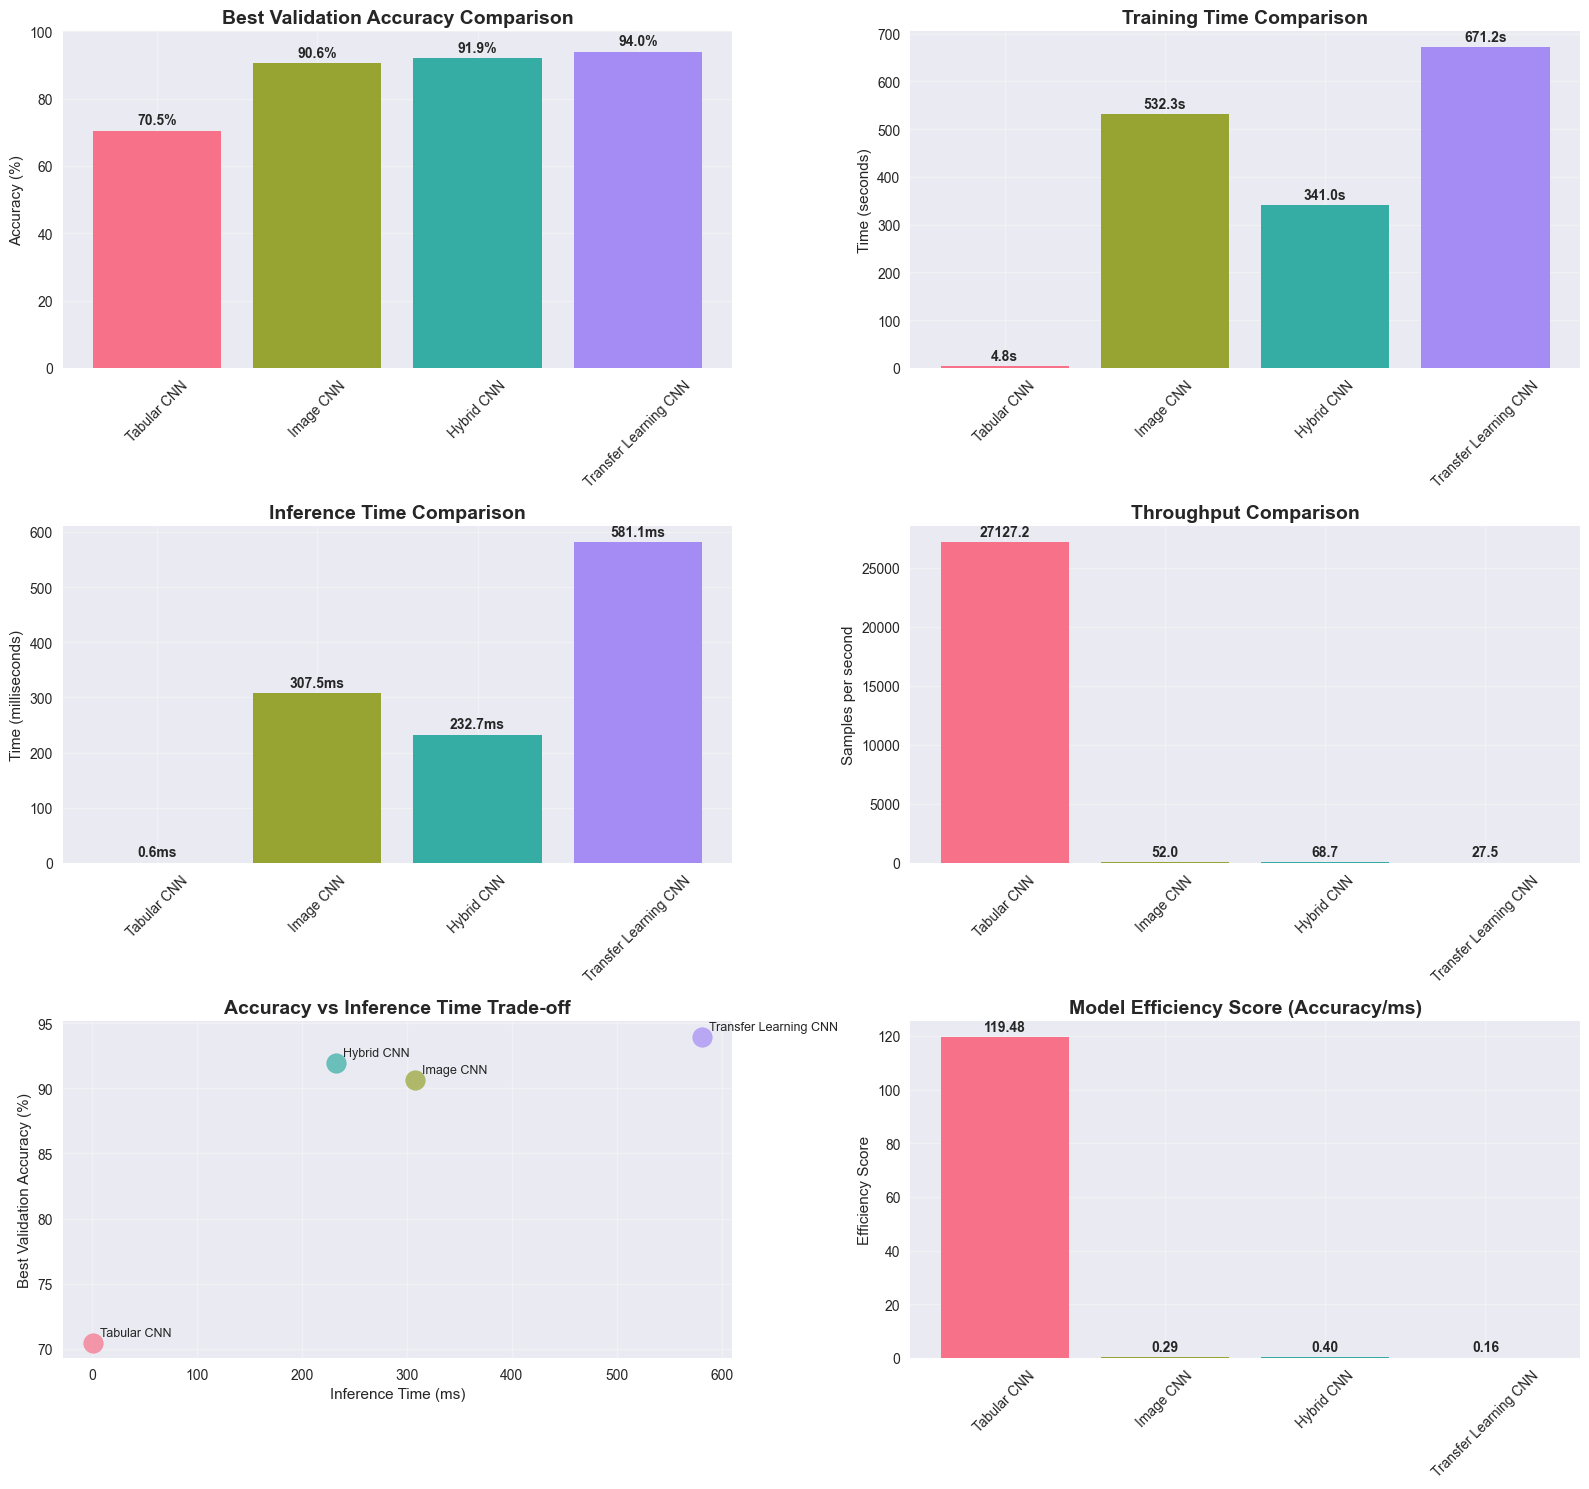

In [15]:
# Add enhanced visualization including inference performance

# Enhanced visualization with inference metrics
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 1. Best Validation Accuracy Comparison (existing)
model_names = comparison_df['Model']
accuracies = comparison_df['Best Validation Accuracy (%)']
colors = sns.color_palette("husl", len(model_names))

bars = axes[0, 0].bar(model_names, accuracies, color=colors)
axes[0, 0].set_title('Best Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(0, 100)
axes[0, 0].grid(True, alpha=0.3)

for bar, acc in zip(bars, accuracies):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                   f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Training Time Comparison (existing)
training_times = comparison_df['Training Time (s)']
bars = axes[0, 1].bar(model_names, training_times, color=colors)
axes[0, 1].set_title('Training Time Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Time (seconds)')
axes[0, 1].grid(True, alpha=0.3)

for bar, time_val in zip(bars, training_times):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(training_times)*0.01, 
                   f'{time_val:.1f}s', ha='center', va='bottom', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. NEW: Inference Time Comparison
inference_times = comparison_df['Inference Time (ms)'].dropna()
valid_models = comparison_df[comparison_df['Inference Time (ms)'].notna()]['Model']
valid_colors = [colors[i] for i in range(len(model_names)) if model_names.iloc[i] in valid_models.values]

bars = axes[1, 0].bar(valid_models, inference_times, color=valid_colors)
axes[1, 0].set_title('Inference Time Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Time (milliseconds)')
axes[1, 0].grid(True, alpha=0.3)

for bar, time_val in zip(bars, inference_times):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(inference_times)*0.01, 
                   f'{time_val:.1f}ms', ha='center', va='bottom', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. NEW: Throughput Comparison
throughputs = comparison_df['Throughput (samples/s)'].dropna()

bars = axes[1, 1].bar(valid_models, throughputs, color=valid_colors)
axes[1, 1].set_title('Throughput Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Samples per second')
axes[1, 1].grid(True, alpha=0.3)

for bar, throughput in zip(bars, throughputs):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(throughputs)*0.01, 
                   f'{throughput:.1f}', ha='center', va='bottom', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. NEW: Accuracy vs Inference Time Scatter Plot
valid_comparison_df = comparison_df.dropna()
for i, row in valid_comparison_df.iterrows():
    model_idx = list(model_names).index(row['Model'])
    axes[2, 0].scatter(row['Inference Time (ms)'], row['Best Validation Accuracy (%)'],
                      s=200, color=colors[model_idx], alpha=0.7, label=row['Model'])
    
    # Add model name as annotation
    axes[2, 0].annotate(row['Model'], 
                       (row['Inference Time (ms)'], row['Best Validation Accuracy (%)']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)

axes[2, 0].set_title('Accuracy vs Inference Time Trade-off', fontsize=14, fontweight='bold')
axes[2, 0].set_xlabel('Inference Time (ms)')
axes[2, 0].set_ylabel('Best Validation Accuracy (%)')
axes[2, 0].grid(True, alpha=0.3)

# 6. NEW: Model Efficiency Score (Accuracy / Inference Time)
efficiency_scores = valid_comparison_df['Best Validation Accuracy (%)'] / valid_comparison_df['Inference Time (ms)']
bars = axes[2, 1].bar(valid_models, efficiency_scores, color=valid_colors)
axes[2, 1].set_title('Model Efficiency Score (Accuracy/ms)', fontsize=14, fontweight='bold')
axes[2, 1].set_ylabel('Efficiency Score')
axes[2, 1].grid(True, alpha=0.3)

for bar, score in zip(bars, efficiency_scores):
    axes[2, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency_scores)*0.01, 
                   f'{score:.2f}', ha='center', va='bottom', fontweight='bold')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [16]:
# Update the detailed inference analysis cell to fix the param_counts error

# Add detailed inference analysis (Fixed version)
print("\n" + "=" * 80)
print("📊 DETAILED INFERENCE PERFORMANCE ANALYSIS")
print("=" * 80)

if inference_results:
    # Create inference summary table
    inference_df = pd.DataFrame.from_dict(inference_results, orient='index')
    inference_df.index.name = 'Model'
    
    print("\n🔍 Inference Time Statistics:")
    print(inference_df.round(2).to_string())
    
    # Performance categories
    print(f"\n📈 Performance Categories:")
    
    # Real-time capability (< 33ms for 30 FPS)
    realtime_threshold = 33  # ms
    realtime_models = []
    
    for model, metrics in inference_results.items():
        avg_time = metrics['avg_time_ms']
        if avg_time < realtime_threshold:
            realtime_models.append(f"{model} ({avg_time:.1f}ms)")
    
    if realtime_models:
        print(f"  🟢 Real-time capable (< {realtime_threshold}ms): {', '.join(realtime_models)}")
    else:
        print(f"  🔴 No models meet real-time requirements (< {realtime_threshold}ms)")
    
    # High throughput models (> 100 samples/sec)
    high_throughput_threshold = 100
    high_throughput_models = []
    
    for model, metrics in inference_results.items():
        throughput = metrics['throughput_samples_per_sec']
        if throughput > high_throughput_threshold:
            high_throughput_models.append(f"{model} ({throughput:.1f} samples/sec)")
    
    if high_throughput_models:
        print(f"  🚀 High throughput (> {high_throughput_threshold} samples/sec): {', '.join(high_throughput_models)}")
    else:
        print(f"  ⚠️ No models achieve high throughput (> {high_throughput_threshold} samples/sec)")
    
    # Memory efficiency estimate (Fixed)
    print(f"\n💾 Model Memory Footprint (estimated):")
    if 'param_counts' in globals():
        for name, model in models_dict.items():
            if name in param_counts:
                # Rough estimate: 4 bytes per parameter + activation memory
                model_size_mb = (param_counts[name] * 4) / (1024 * 1024)
                print(f"  • {name}: ~{model_size_mb:.1f} MB")
    else:
        # Calculate on the fly if param_counts not available
        for name, model in models_dict.items():
            param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
            model_size_mb = (param_count * 4) / (1024 * 1024)
            print(f"  • {name}: {param_count:,} params (~{model_size_mb:.1f} MB)")
    
    # Deployment recommendations
    print(f"\n🎯 Deployment Recommendations:")
    
    # Find best balanced model (consider accuracy and speed)
    if len(valid_comparison_df) > 0:
        # Normalize metrics for fair comparison
        norm_acc = (valid_comparison_df['Best Validation Accuracy (%)'] - valid_comparison_df['Best Validation Accuracy (%)'].min()) / \
                   (valid_comparison_df['Best Validation Accuracy (%)'].max() - valid_comparison_df['Best Validation Accuracy (%)'].min())
        
        norm_speed = (valid_comparison_df['Inference Time (ms)'].max() - valid_comparison_df['Inference Time (ms)']) / \
                     (valid_comparison_df['Inference Time (ms)'].max() - valid_comparison_df['Inference Time (ms)'].min())
        
        balance_score = (norm_acc + norm_speed) / 2
        best_balanced_idx = balance_score.idxmax()
        best_balanced_model = valid_comparison_df.loc[best_balanced_idx, 'Model']
        
        print(f"  🎯 Best balanced model: {best_balanced_model}")
        print(f"     Accuracy: {valid_comparison_df.loc[best_balanced_idx, 'Best Validation Accuracy (%)']:.1f}%")
        print(f"     Inference: {valid_comparison_df.loc[best_balanced_idx, 'Inference Time (ms)']:.1f}ms")
        print(f"     Throughput: {valid_comparison_df.loc[best_balanced_idx, 'Throughput (samples/s)']:.1f} samples/sec")
    
    # Use case recommendations
    print(f"\n📱 Use Case Recommendations:")
    print(f"  • Real-time monitoring: Choose models with < 33ms inference time")
    print(f"  • Batch processing: Prioritize accuracy over speed")
    print(f"  • Edge deployment: Consider Tabular CNN for low resource usage")
    print(f"  • High accuracy needs: Use Transfer Learning or Hybrid models")
    print(f"  • Production deployment: Balance accuracy, speed, and resource usage")

else:
    print("❌ No inference results available. Ensure models are trained and images exist.")


📊 DETAILED INFERENCE PERFORMANCE ANALYSIS

🔍 Inference Time Statistics:
                       avg_time_ms  std_time_ms  min_time_ms  max_time_ms  throughput_samples_per_sec
Model                                                                                                
Tabular CNN                   0.59         0.68          0.0         5.01                    27127.19
Image CNN                   307.49        20.71        275.0       419.00                       52.03
Hybrid CNN                  232.73        41.95        208.0       624.00                       68.75
Transfer Learning CNN       581.14       126.83        449.0      1251.00                       27.53

📈 Performance Categories:
  🟢 Real-time capable (< 33ms): Tabular CNN (0.6ms)
  🚀 High throughput (> 100 samples/sec): Tabular CNN (27127.2 samples/sec)

💾 Model Memory Footprint (estimated):
  • Tabular CNN: ~0.0 MB
  • Image CNN: ~196.4 MB
  • Hybrid CNN: ~98.1 MB
  • Transfer Learning CNN: ~42.6 MB

🎯 Deployme

In [17]:
# Enhanced comparison table with parameter counts

# Create enhanced comparison summary with parameter counts
comparison_df_enhanced = pd.DataFrame({
    'Model': list(results.keys()),
    'Parameters': [param_counts[model] if model in param_counts else 0 for model in results.keys()],
    'Model Size (MB)': [(param_counts[model] * 4) / (1024 * 1024) if model in param_counts else 0 for model in results.keys()],
    'Best Validation Accuracy (%)': [results[model]['best_val_acc'] for model in results.keys()],
    'Training Time (s)': [results[model]['training_time'] for model in results.keys()],
    'Inference Time (ms)': [inference_results[model]['avg_time_ms'] if model in inference_results else np.nan for model in results.keys()],
    'Throughput (samples/s)': [inference_results[model]['throughput_samples_per_sec'] if model in inference_results else np.nan for model in results.keys()],
    'Final Train Accuracy (%)': [results[model]['history']['train_acc'][-1] for model in results.keys()],
    'Final Validation Accuracy (%)': [results[model]['history']['val_acc'][-1] for model in results.keys()]
})

print("\n" + "=" * 120)
print("🏆 ENHANCED RESULTS COMPARISON (Including Model Size & Parameters)")
print("=" * 120)
print(comparison_df_enhanced.to_string(index=False))
print("=" * 120)

# Find lightest model (fewest parameters)
lightest_model_idx = comparison_df_enhanced['Parameters'].idxmin()
lightest_model = comparison_df_enhanced.iloc[lightest_model_idx]['Model']
lightest_params = comparison_df_enhanced.iloc[lightest_model_idx]['Parameters']

print(f"\n🪶 LIGHTEST MODEL: {lightest_model} with {lightest_params:,} parameters")
print(f"🥇 BEST ACCURACY: {best_accuracy_model} with {best_accuracy_value:.2f}%")
print(f"⚡ FASTEST INFERENCE: {fastest_inference_model} with {fastest_inference_time:.2f} ms")
print(f"🚀 HIGHEST THROUGHPUT: {highest_throughput_model} with {highest_throughput_value:.1f} samples/sec")


🏆 ENHANCED RESULTS COMPARISON (Including Model Size & Parameters)
                Model  Parameters  Model Size (MB)  Best Validation Accuracy (%)  Training Time (s)  Inference Time (ms)  Throughput (samples/s)  Final Train Accuracy (%)  Final Validation Accuracy (%)
          Tabular CNN       11426         0.043587                     70.469799           4.774000             0.589814            27127.187472                 65.709459                      67.114094
            Image CNN    51475010       196.361580                     90.604027         532.292142           307.488625               52.034445                 94.594595                      90.604027
           Hybrid CNN    25722594        98.123909                     91.946309         340.988994           232.734220               68.747948                 98.479730                      91.946309
Transfer Learning CNN    11177538        42.638924                     93.959732         671.217493           581.136601     

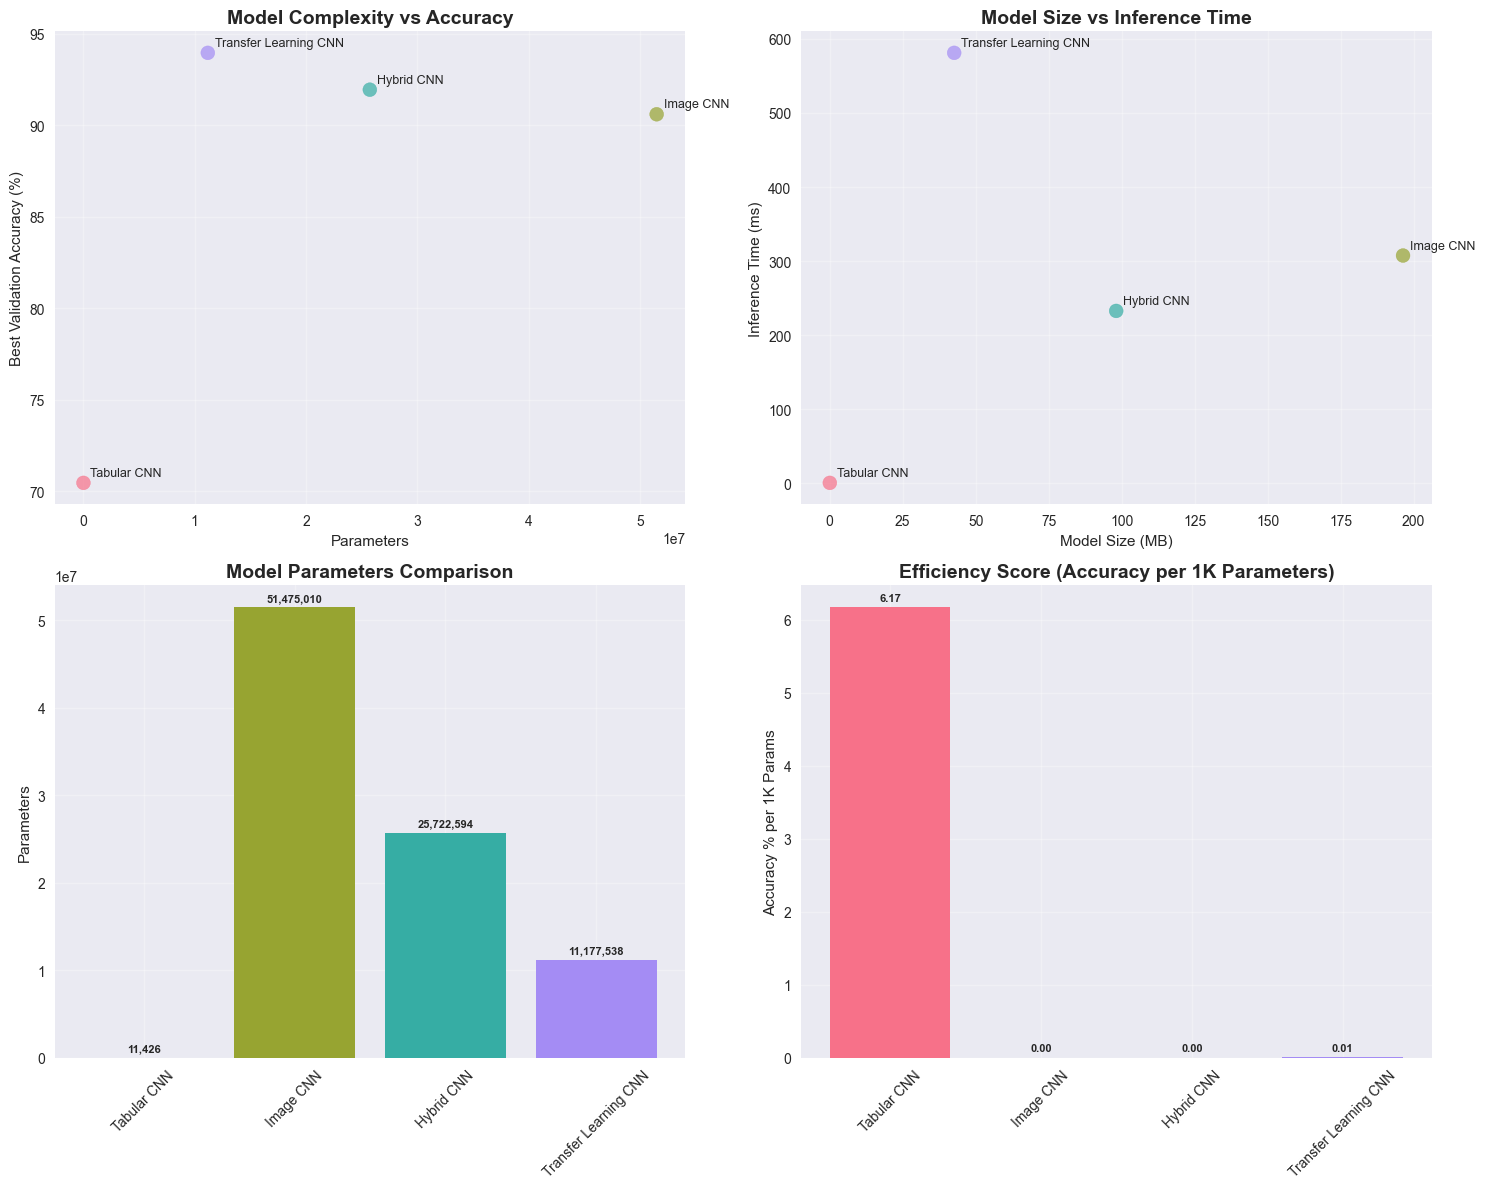

In [18]:
# Add visualization for model complexity vs performance

# Model Complexity vs Performance Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Filter valid data for plotting
valid_df = comparison_df_enhanced.dropna()

# 1. Parameters vs Accuracy
axes[0, 0].scatter(valid_df['Parameters'], valid_df['Best Validation Accuracy (%)'], 
                   s=100, alpha=0.7, c=colors[:len(valid_df)])
for i, row in valid_df.iterrows():
    axes[0, 0].annotate(row['Model'], 
                       (row['Parameters'], row['Best Validation Accuracy (%)']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0, 0].set_title('Model Complexity vs Accuracy', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Parameters')
axes[0, 0].set_ylabel('Best Validation Accuracy (%)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Model Size vs Inference Time
axes[0, 1].scatter(valid_df['Model Size (MB)'], valid_df['Inference Time (ms)'], 
                   s=100, alpha=0.7, c=colors[:len(valid_df)])
for i, row in valid_df.iterrows():
    axes[0, 1].annotate(row['Model'], 
                       (row['Model Size (MB)'], row['Inference Time (ms)']),
                       xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[0, 1].set_title('Model Size vs Inference Time', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Model Size (MB)')
axes[0, 1].set_ylabel('Inference Time (ms)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Parameters comparison (bar chart)
bars = axes[1, 0].bar(valid_df['Model'], valid_df['Parameters'], 
                      color=colors[:len(valid_df)])
axes[1, 0].set_title('Model Parameters Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Parameters')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

for bar, params in zip(bars, valid_df['Parameters']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(valid_df['Parameters'])*0.01, 
                   f'{params:,}', ha='center', va='bottom', fontweight='bold', fontsize=8)

# 4. Efficiency vs Complexity (Accuracy per Parameter)
efficiency_per_param = valid_df['Best Validation Accuracy (%)'] / (valid_df['Parameters'] / 1000)  # per 1K params
bars = axes[1, 1].bar(valid_df['Model'], efficiency_per_param, 
                      color=colors[:len(valid_df)])
axes[1, 1].set_title('Efficiency Score (Accuracy per 1K Parameters)', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Accuracy % per 1K Params')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

for bar, eff in zip(bars, efficiency_per_param):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(efficiency_per_param)*0.01, 
                   f'{eff:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained Transfer Learning CNN model
if 'Transfer Learning CNN' in models_dict:
    transfer_model_path = 'models/transfer_learning_cnn.pth'
    os.makedirs(os.path.dirname(transfer_model_path), exist_ok=True)
    torch.save(models_dict['Transfer Learning CNN'].state_dict(), transfer_model_path)
    print(f"✅ Transfer Learning CNN model saved to {transfer_model_path}")
else:
    print("❌ Transfer Learning CNN model not found.")

✅ Transfer Learning CNN model saved to models/transfer_learning_cnn.pth
